## Домашнее задание 4
### Задача классификации и логистическая регрессия

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

Загрузим данные, здесь они сразу поделены на train и test (тестовую/вадидационную) части.

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

train_data

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


In [3]:
test_data

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


Удостоверимся, что классов два:

In [4]:
np.unique(train_data["satisfaction"])

array(['neutral or dissatisfied', 'satisfied'], dtype=object)

Также уберём столбец *id*, т.к. он не несёт полезной информации.

In [5]:
train_data = train_data.drop(["id", "Unnamed: 0"], axis=1)
test_data = test_data.drop(["id", "Unnamed: 0"], axis=1)

### Задание 1. Подготовка данных.

Выделите отдельный столбец для таргета (satisfaction). В качестве метки *True* возьмите *"satisfied"*.

In [ ]:
train_target = ...
test_target = ...

assert train_data.shape[0] == train_target.shape[0]
assert test_data.shape[0] == test_target.shape[0]
assert train_target.sum() == 45025, "Возможно, вы перепутали метки классов"

Удалите из train_data и test_data столбец с таргетом. Будьте внимательны, после удаления не перезапускайте предыдущую ячейку, ведь столбца с таргетом уже не будет в данных!

In [ ]:
train_data = ...
test_data = ...

assert train_data.shape[1] == 22
assert test_data.shape[1] == 22

Теперь нужно заэнкодить фичи. Их тут довольно много, придётся поработать.

In [ ]:
print("Количество различных значений")
print(train_data.nunique())

In [ ]:
print(train_data.dtypes)

Мы видим, что все фичи делятся на бинарные, численные и одну категориальную (`Class`).

Заэнкодьте бинарные фичи с помощью `OrdinalEncoder`, а оставшуюся категориальную с помощью `OneHotEncoder`. *Важно: fit нужно делать только на train данных, test - только transform!*

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Скопируем данные, чтобы случайно ничего не затереть
train_data_encoded = train_data.copy()
test_data_encoded = test_data.copy()
# Перечислите бинарные фичи
binary_features = [...]

ordinal_enc = OrdinalEncoder()
onehot_enc = OneHotEncoder()
# Закодируйте бинарные фичи
train_data_encoded[binary_features] = ...
test_data_encoded[binary_features] = ...

assert train_data_encoded.shape == (103904, 22), "Количество строк и столбцов не должно поменяться"
assert len(ordinal_enc.categories_) == 3, "В таблице 3 бинарные фичи"
# Закодируйте категориальную фичу
train_data_onehot_encoding = ...
test_data_onehot_encoding = ...

assert train_data_onehot_encoding.shape == (103904, 3), "Должно получится 3 класса"

# Добавим колонки, соответствующие one-hot кодированию класса
class_columns = [f"Class_{i}" for i in range(train_data_onehot_encoding.shape[1])]
train_data_encoded[class_columns] = train_data_onehot_encoding.toarray()
test_data_encoded[class_columns] = test_data_onehot_encoding.toarray()
# Уберём старый столбец класса
train_data_encoded = train_data_encoded.drop(["Class"], axis=1)
test_data_encoded = test_data_encoded.drop(["Class"], axis=1)

train_data_encoded

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_0,Class_1,Class_2
0,1.0,0.0,13,1.0,460,3,4,3,1,5,...,3,4,4,5,5,25,18.0,0.0,0.0,1.0
1,1.0,1.0,25,0.0,235,3,2,3,3,1,...,5,3,1,4,1,1,6.0,1.0,0.0,0.0
2,0.0,0.0,26,0.0,1142,2,2,2,2,5,...,3,4,4,4,5,0,0.0,1.0,0.0,0.0
3,0.0,0.0,25,0.0,562,2,5,5,5,2,...,5,3,1,4,2,11,9.0,1.0,0.0,0.0
4,1.0,0.0,61,0.0,214,3,3,3,3,4,...,4,4,3,3,3,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,0.0,1.0,23,0.0,192,2,1,2,3,2,...,1,4,2,3,2,3,0.0,0.0,1.0,0.0
103900,1.0,0.0,49,0.0,2347,4,4,4,4,2,...,5,5,5,5,4,0,0.0,1.0,0.0,0.0
103901,1.0,1.0,30,0.0,1995,1,1,1,3,4,...,2,4,5,5,4,7,14.0,1.0,0.0,0.0
103902,0.0,1.0,22,0.0,1000,1,1,1,5,1,...,5,1,5,4,1,0,0.0,0.0,1.0,0.0


### Задание 2. Отсутствующие значения.

В этой таблице есть ещё одна трудность - в ней есть отсутсвующие значения (*NaN*). Давайте отыщем их:

In [ ]:
train_data_encoded.isna().sum()

Мы видим, что NaN-ы встречаются в столбце `Arrival Delay in Minutes` - опоздание прибытия самолёта. Нужно что-то сделать с этими ячейками перед тем, как обучать модель. Логично предположить, что когда отсутствует информация об опоздании самолёта, то это значит, что опоздания не было, т.е. оно равно нулю. Замените все значения *NaN* на 0.

*Для получения маски элементов, равных NaN используйте `.isna()`.*

In [ ]:
train_mask = ... # Используйте .isna() на нужном столбце
train_data_encoded.loc[train_mask, ...] = ... # Замените все NaN в нужном столбце на 0
test_mask = ...
test_data_encoded.loc[test_mask, ...] = ...

assert not train_data_encoded.isna().any().any(), "Все NaN должны быть заменены на 0"
assert not test_data_encoded.isna().any().any(), "Все NaN должны быть заменены на 0"

**В дальнейшем работайте с `train_data_encoded` и `test_data_encoded`.**

### Задание 3. Подсчёт метрик.

Для начала сделаем модель, выдающую всегда значение *"satisfied"* (*True*). Посчитайте для неё значения accuracy, recall и precision, **не используя готовые библиотечные функции**.

In [ ]:
predictions = np.array([True] * test_data_encoded.shape[0])

accuracy = ...
recall = ...
precision = ...

print(f"Accuracy: {accuracy:.4f}, recall: {recall:.4f}, precision: {precision:.4f}")

assert np.allclose(accuracy, accuracy_score(test_target, predictions)), "Неправильный accuracy"
assert np.allclose(recall, recall_score(test_target, predictions)), "Неправильный recall"
assert np.allclose(precision, precision_score(test_target, predictions)), "Неправильный precision"

Обучите KNN классификацию и подсчитайте те же метрики.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=...)
... # Обучите модель
predictions = ... # Получите предсказания

accuracy = ...
recall = ...
precision = ...

print(f"Accuracy: {accuracy:.4f}, recall: {recall:.4f}, precision: {precision:.4f}")

assert np.allclose(accuracy, accuracy_score(test_target, predictions)), "Неправильный accuracy"
assert np.allclose(recall, recall_score(test_target, predictions)), "Неправильный recall"
assert np.allclose(precision, precision_score(test_target, predictions)), "Неправильный precision"

assert accuracy < 0.75, "Accuracy слишком высокий, попробуйте изменить количество соседей"
assert recall < 0.67, "Recall слишком высокий, попробуйте изменить количество соседей"
assert precision < 0.75, "Precision слишком высокий, попробуйте изменить количество соседей"

Accuracy: 0.7467, recall: 0.6675, precision: 0.7319


Заметили долгое время работы программы? Это запоминание данных и расчёт предсказаний, который занимает достаточно много времени у KNN - его главный минус.

### Задание 4. Ручная логистическая регрессия

Попробуйте вручную подобрать коэффициенты логистической регрессии, чтобы получить побольше метрики.

In [15]:
# Генерация данных
np.random.seed(42)
samples1 = np.random.multivariate_normal([-1, 0], np.eye(2) * 2, 200)
samples2 = np.random.multivariate_normal([1, 2], np.eye(2) / 2, 200)
X = np.vstack([samples1, samples2])
y = np.array([0]*200 + [1]*200)

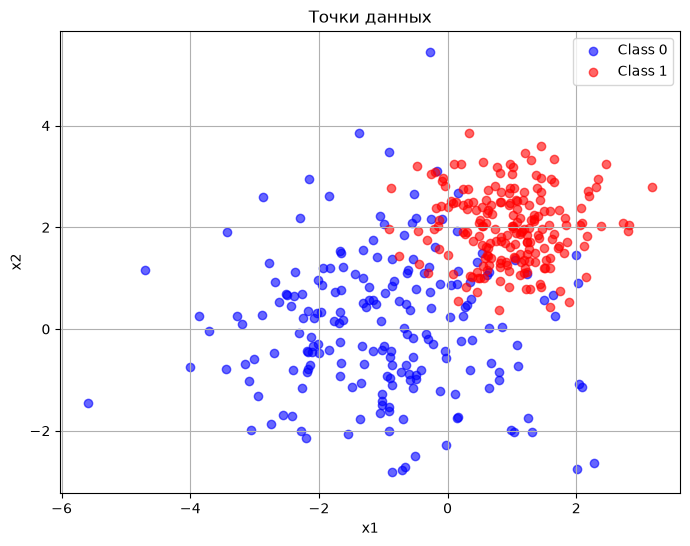

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', alpha=0.6, label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', alpha=0.6, label='Class 1')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Точки данных")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Вспомогательная функция для рисовния границы
def plot_decision_boundary(X, y, beta, b, c=0.5, title="Данные с границей (области классов показаны)"):
    """
    Рисует двумерные точки (X, y) и границу логистической регрессии с коэффициентами beta и b.
    Также визуализирует области классов.

    X: np.array (n_samples, 2)
    y: np.array (n_samples, )
    beta: длина 2, коэффициенты при x1 и x2
    b: float, bias (свободный член)
    c: float, порог для классификации
    title: Заголовок графика
    """
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', alpha=0.6, label='Class 0')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', alpha=0.6, label='Class 1')

    t_boundary = np.log(c / (1 - c))

    x1_vals = np.linspace(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1, 200)
    x2_vals = (t_boundary - b - x1_vals * beta[0]) / beta[1]
    plt.plot(x1_vals, x2_vals, color='green', linewidth=2, label='Граница классификации')

    x1_grid = np.linspace(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1, 500)
    x2_boundary = (t_boundary - b - x1_grid * beta[0]) / beta[1]

    if beta[1] < 0:
        plt.fill_between(x1_grid, x2_boundary, np.max(X[:, 1]) + 2, color='blue', alpha=0.1, label='Предсказываем 0')
        plt.fill_between(x1_grid, np.min(X[:, 1]) - 2, x2_boundary, color='red', alpha=0.1, label='Предсказываем 1')
    else:
        plt.fill_between(x1_grid, x2_boundary, np.max(X[:, 1]) + 2, color='red', alpha=0.1, label='Предсказываем 1')
        plt.fill_between(x1_grid, np.min(X[:, 1]) - 2, x2_boundary, color='blue', alpha=0.1, label='Предсказываем 0')

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()

Реализуйте функцию сигмоиды от числа.

In [ ]:
def sigmoid(t):
    return ... # Напишите формулу сигмоиды, для экспоненты используйте функцию np.exp()

assert np.allclose(sigmoid(0), 0.5), "Неправильная сигмоида"
assert np.allclose(sigmoid(100), 1), "Неправильная сигмоида"
assert np.allclose(sigmoid(-100), 0), "Неправильная сигмоида"

In [ ]:
beta = [..., ...] # Подберите значения параметров
b = ... # Подберите значения параметра

t = ... # Вход в сигмоиду (выход линейной регрессии)
y_pred = sigmoid(t)

c = 0.5 # Можете менять и этот параметр тоже
y_pred_class = y_pred > c
accuracy = accuracy_score(y, y_pred_class)

print(f"Accuracy: {accuracy:.4f}")

# Теперь вызов функции для текущих значений:
plot_decision_boundary(X, y, beta, b, c)

assert accuracy > 0.91, "Accuracy слишком низкий"

Теперь тоже самое только для precision. Однако постарайтесь не слишком сильно уменьшить accuracy!

In [ ]:
beta = [..., ...]
b = ...

t = ...
y_pred = sigmoid(t)

c = 0.5
y_pred_class = y_pred > c
accuracy = accuracy_score(y, y_pred_class)
precision = precision_score(y, y_pred_class)

print(f"Accuracy: {accuracy:.4f}, precision: {precision:.4f}")

# Теперь вызов функции для текущих значений:
plot_decision_boundary(X, y, beta, b, c)

assert accuracy > 0.8, "Accuracy слишком низкий"
assert precision > 0.95, "Precision слишком низкий"

Как мы видим, увеличение одной метрики далеко не всегда влечёт увеличение другой, а иногда вовсе мешает. Задача аналитиков и MLщиков довольно часто состоит в том, чтобы правильно выбрать метрики для данной задачи.